In [26]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style for better plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [27]:
# Set the dataset path (adjust if needed)
DATASET_PATH = '/kaggle/input/human-bone-fractures-image-dataset'

# Explore the directory structure
def explore_directory(path, max_depth=3, current_depth=0):
    """Recursively explore directory structure"""
    items = []
    if current_depth <= max_depth:
        try:
            for item in os.listdir(path):
                item_path = os.path.join(path, item)
                if os.path.isdir(item_path):
                    items.append(f"{'  ' * current_depth}📁 {item}/")
                    items.extend(explore_directory(item_path, max_depth, current_depth + 1))
                else:
                    items.append(f"{'  ' * current_depth}📄 {item}")
        except PermissionError:
            items.append(f"{'  ' * current_depth}❌ Permission denied")
    return items

print("Dataset Directory Structure:")
print("\n".join(explore_directory("/kaggle/input/human-bone-fractures-image-dataset")))

Dataset Directory Structure:
📁 Human Bone Fractures Multi-modal Image Dataset (HBFMID)/
  📁 Bone Fractures Detection/
    📄 README.roboflow.txt
    📄 data.yaml
    📁 valid/
      📁 labels/
      📁 images/
    📁 test/
      📁 labels/
      📁 images/
    📁 train/
      📁 labels/
      📁 images/


In [28]:
# Function to collect dataset information
def analyze_dataset_structure(base_path):
    dataset_info = {
        'directories': [],
        'total_images': 0,
        'file_extensions': Counter(),
        'directory_stats': {}
    }
    
    for root, dirs, files in os.walk(base_path):
        # Filter image files
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.dcm'))]
        
        if image_files:
            rel_path = os.path.relpath(root, base_path)
            dataset_info['directories'].append(rel_path)
            dataset_info['directory_stats'][rel_path] = len(image_files)
            dataset_info['total_images'] += len(image_files)
            
            # Count file extensions
            for file in image_files:
                ext = os.path.splitext(file)[1].lower()
                dataset_info['file_extensions'][ext] += 1
    
    return dataset_info

# Analyze the dataset
dataset_info = analyze_dataset_structure(DATASET_PATH)

print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Total Images: {dataset_info['total_images']:,}")
print(f"Number of Directories: {len(dataset_info['directories'])}")
print(f"File Extensions: {dict(dataset_info['file_extensions'])}")

📊 DATASET OVERVIEW
Total Images: 1,539
Number of Directories: 3
File Extensions: {'.jpg': 1539}


In [29]:
# Create a comprehensive DataFrame with image information
def create_image_dataframe(base_path):
    image_data = []
    
    for root, dirs, files in os.walk(base_path):
        image_files = [f for f in files if f.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp', '.tiff', '.dcm'))]
        
        for file in image_files:
            file_path = os.path.join(root, file)
            rel_path = os.path.relpath(root, base_path)
            
            try:
                # Get file size
                file_size = os.path.getsize(file_path)
                
                # Try to open image and get dimensions
                try:
                    with Image.open(file_path) as img:
                        width, height = img.size
                        mode = img.mode
                except:
                    # If PIL fails, try with OpenCV
                    try:
                        img = cv2.imread(file_path)
                        height, width = img.shape[:2]
                        mode = 'BGR' if len(img.shape) == 3 else 'GRAY'
                    except:
                        width, height, mode = None, None, None
                
                image_data.append({
                    'filename': file,
                    'filepath': file_path,
                    'directory': rel_path,
                    'file_size_mb': file_size / (1024 * 1024),
                    'width': width,
                    'height': height,
                    'mode': mode,
                    'extension': os.path.splitext(file)[1].lower(),
                    'aspect_ratio': width / height if width and height else None
                })
                
            except Exception as e:
                print(f"Error processing {file_path}: {e}")
    
    return pd.DataFrame(image_data)

# Create the DataFrame
print("Creating image metadata DataFrame...")
df = create_image_dataframe(DATASET_PATH)

print(f"✅ DataFrame created with {len(df)} images")
print("\n📋 DataFrame Info:")
print(df.info())

Creating image metadata DataFrame...
✅ DataFrame created with 1539 images

📋 DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1539 entries, 0 to 1538
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   filename      1539 non-null   object 
 1   filepath      1539 non-null   object 
 2   directory     1539 non-null   object 
 3   file_size_mb  1539 non-null   float64
 4   width         1539 non-null   int64  
 5   height        1539 non-null   int64  
 6   mode          1539 non-null   object 
 7   extension     1539 non-null   object 
 8   aspect_ratio  1539 non-null   float64
dtypes: float64(2), int64(2), object(5)
memory usage: 108.3+ KB
None


In [30]:
# Display basic statistics
print("📈 BASIC STATISTICS")
print("=" * 50)
print(df.describe())

print("\n🏷️ CATEGORICAL VARIABLES")
print("=" * 30)
print("Directory distribution:")
print(df['directory'].value_counts())

print("\nFile extension distribution:")
print(df['extension'].value_counts())

print("\nImage mode distribution:")
print(df['mode'].value_counts())

📈 BASIC STATISTICS
       file_size_mb   width  height  aspect_ratio
count   1539.000000  1539.0  1539.0        1539.0
mean       0.025554   640.0   640.0           1.0
std        0.005775     0.0     0.0           0.0
min        0.011937   640.0   640.0           1.0
25%        0.021500   640.0   640.0           1.0
50%        0.024757   640.0   640.0           1.0
75%        0.028863   640.0   640.0           1.0
max        0.064954   640.0   640.0           1.0

🏷️ CATEGORICAL VARIABLES
Directory distribution:
directory
Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/train/images    1347
Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid/images     128
Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images       64
Name: count, dtype: int64

File extension distribution:
extension
.jpg    1539
Name: count, dtype: int64

Image mode distribution:
mode
RGB    1539
Name: count, dtyp

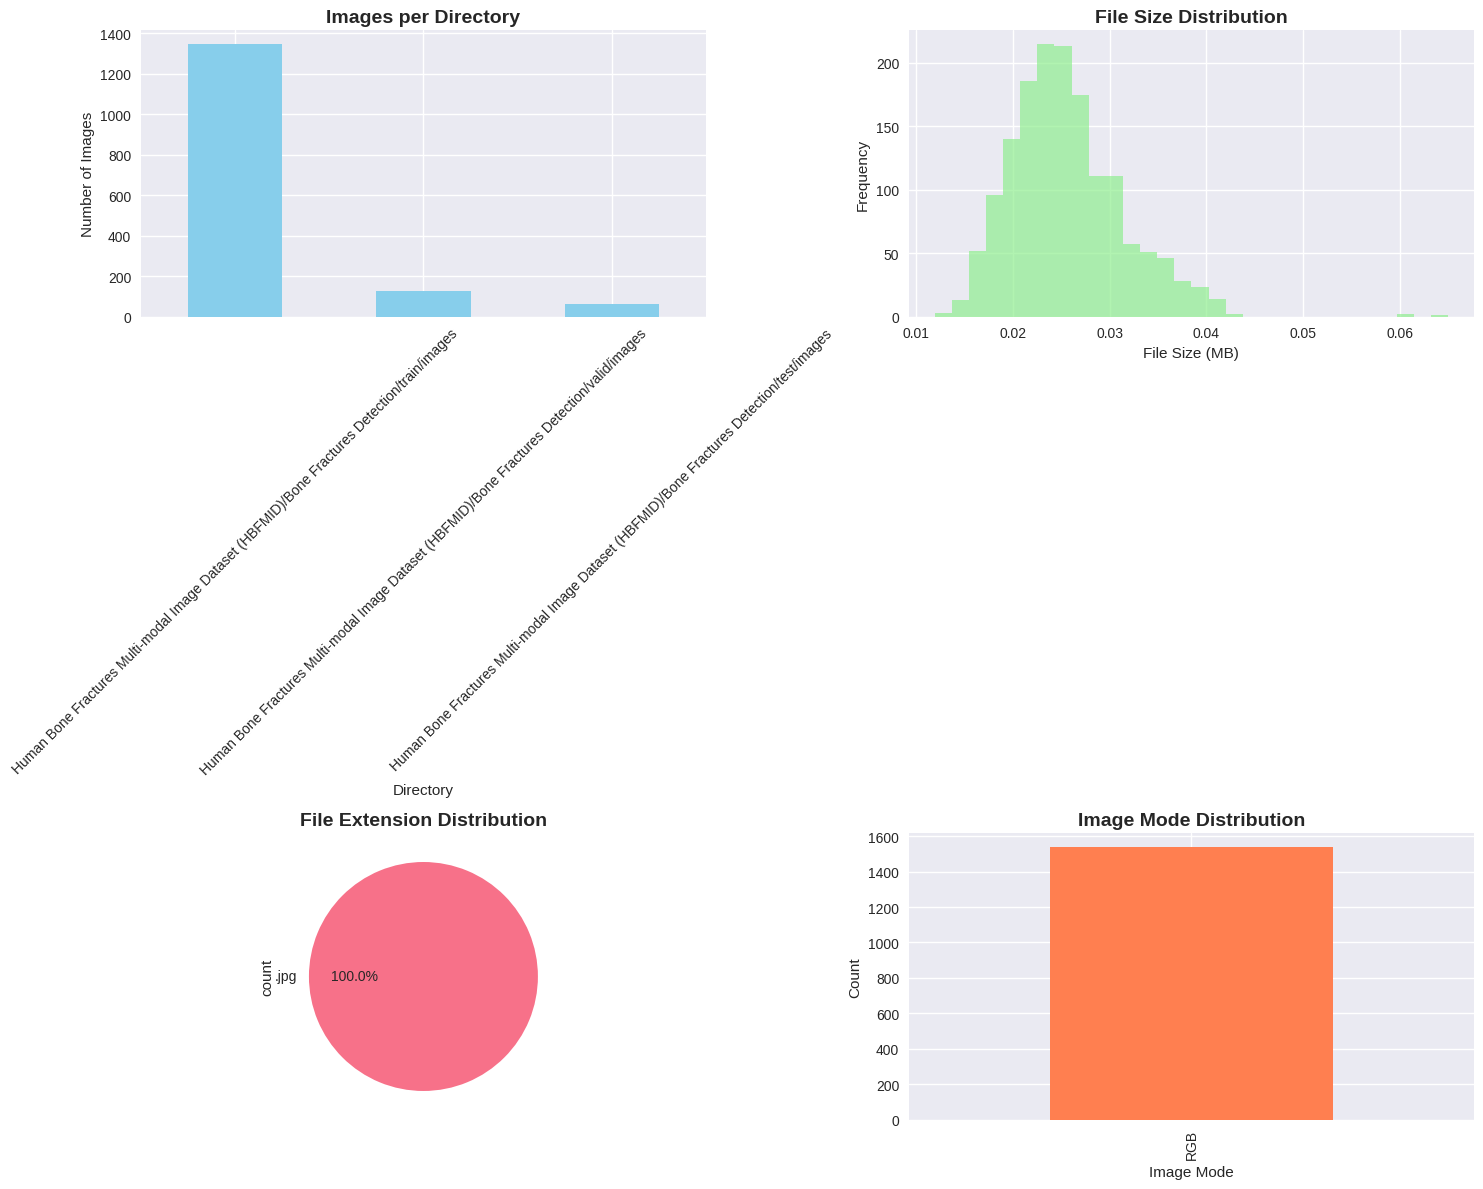

In [31]:
# Create visualization for dataset distribution
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Directory distribution
df['directory'].value_counts().plot(kind='bar', ax=axes[0,0], color='skyblue')
axes[0,0].set_title('Images per Directory', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Directory')
axes[0,0].set_ylabel('Number of Images')
axes[0,0].tick_params(axis='x', rotation=45)

# File size distribution
axes[0,1].hist(df['file_size_mb'].dropna(), bins=30, color='lightgreen', alpha=0.7)
axes[0,1].set_title('File Size Distribution', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('File Size (MB)')
axes[0,1].set_ylabel('Frequency')

# Extension distribution
df['extension'].value_counts().plot(kind='pie', ax=axes[1,0], autopct='%1.1f%%')
axes[1,0].set_title('File Extension Distribution', fontsize=14, fontweight='bold')

# Image mode distribution
df['mode'].value_counts().plot(kind='bar', ax=axes[1,1], color='coral')
axes[1,1].set_title('Image Mode Distribution', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Image Mode')
axes[1,1].set_ylabel('Count')

plt.tight_layout()
plt.show()

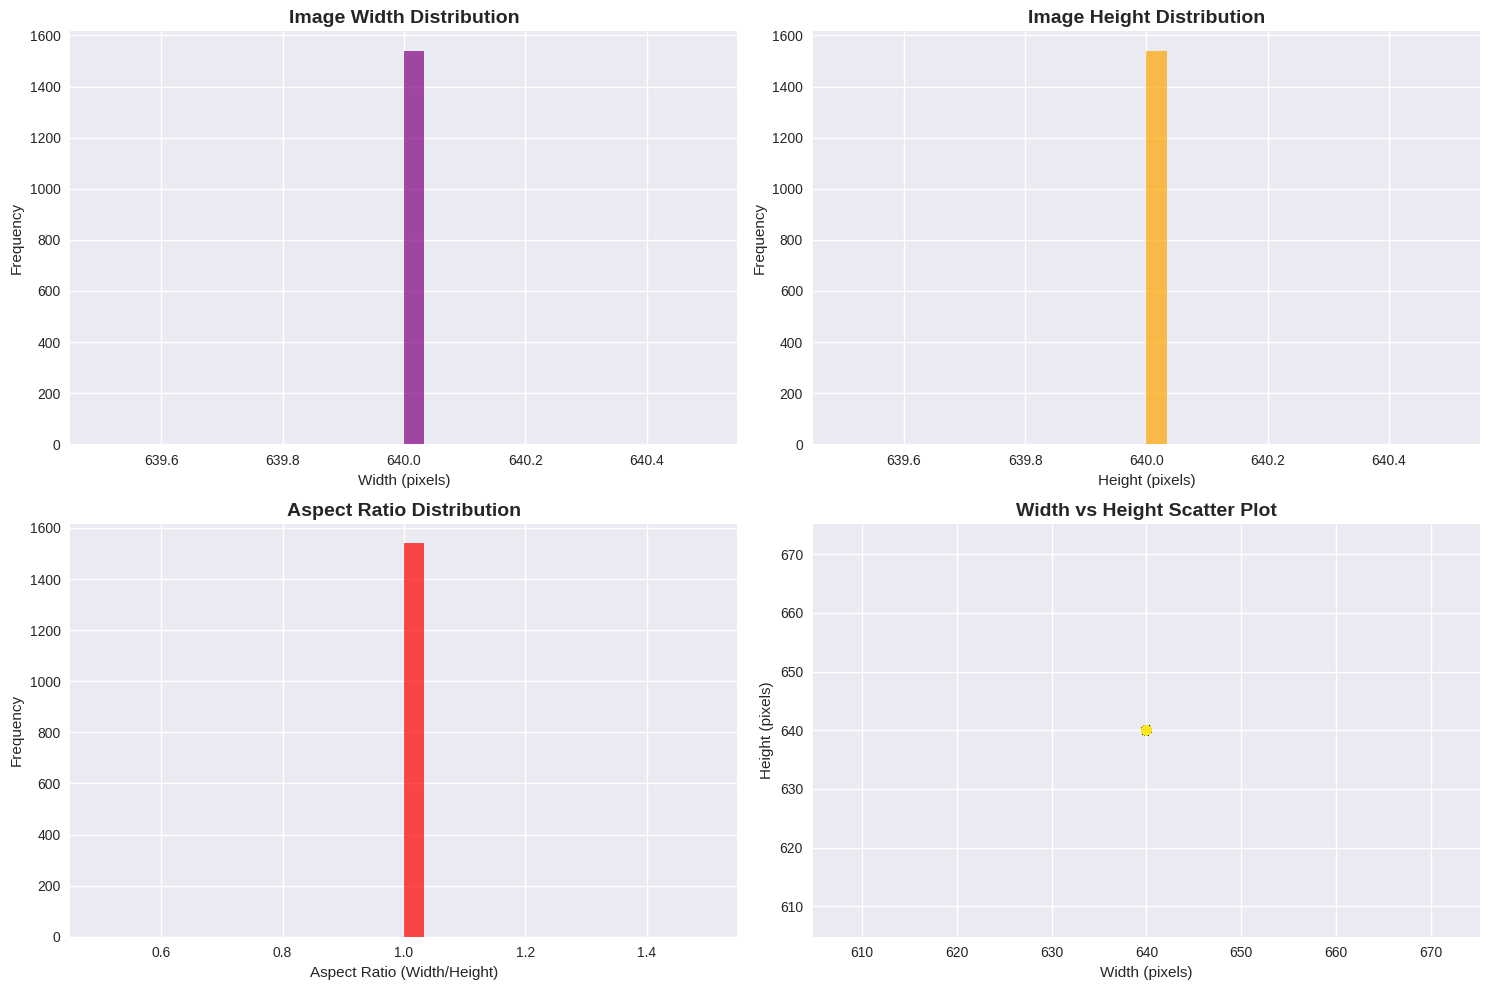

📏 IMAGE DIMENSION STATISTICS
Width - Min: 640, Max: 640, Mean: 640.0
Height - Min: 640, Max: 640, Mean: 640.0
Aspect Ratio - Min: 1.000, Max: 1.000, Mean: 1.000


In [32]:
# Analyze image dimensions
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Width distribution
axes[0,0].hist(df['width'].dropna(), bins=30, color='purple', alpha=0.7)
axes[0,0].set_title('Image Width Distribution', fontsize=14, fontweight='bold')
axes[0,0].set_xlabel('Width (pixels)')
axes[0,0].set_ylabel('Frequency')

# Height distribution
axes[0,1].hist(df['height'].dropna(), bins=30, color='orange', alpha=0.7)
axes[0,1].set_title('Image Height Distribution', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Height (pixels)')
axes[0,1].set_ylabel('Frequency')

# Aspect ratio distribution
axes[1,0].hist(df['aspect_ratio'].dropna(), bins=30, color='red', alpha=0.7)
axes[1,0].set_title('Aspect Ratio Distribution', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Aspect Ratio (Width/Height)')
axes[1,0].set_ylabel('Frequency')

# Width vs Height scatter plot
scatter = axes[1,1].scatter(df['width'], df['height'], alpha=0.6, c=df.index, cmap='viridis')
axes[1,1].set_title('Width vs Height Scatter Plot', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('Width (pixels)')
axes[1,1].set_ylabel('Height (pixels)')

plt.tight_layout()
plt.show()

# Print dimension statistics
print("📏 IMAGE DIMENSION STATISTICS")
print("=" * 40)
print(f"Width - Min: {df['width'].min()}, Max: {df['width'].max()}, Mean: {df['width'].mean():.1f}")
print(f"Height - Min: {df['height'].min()}, Max: {df['height'].max()}, Mean: {df['height'].mean():.1f}")
print(f"Aspect Ratio - Min: {df['aspect_ratio'].min():.3f}, Max: {df['aspect_ratio'].max():.3f}, Mean: {df['aspect_ratio'].mean():.3f}")

🖼️ SAMPLE IMAGES FROM DATASET


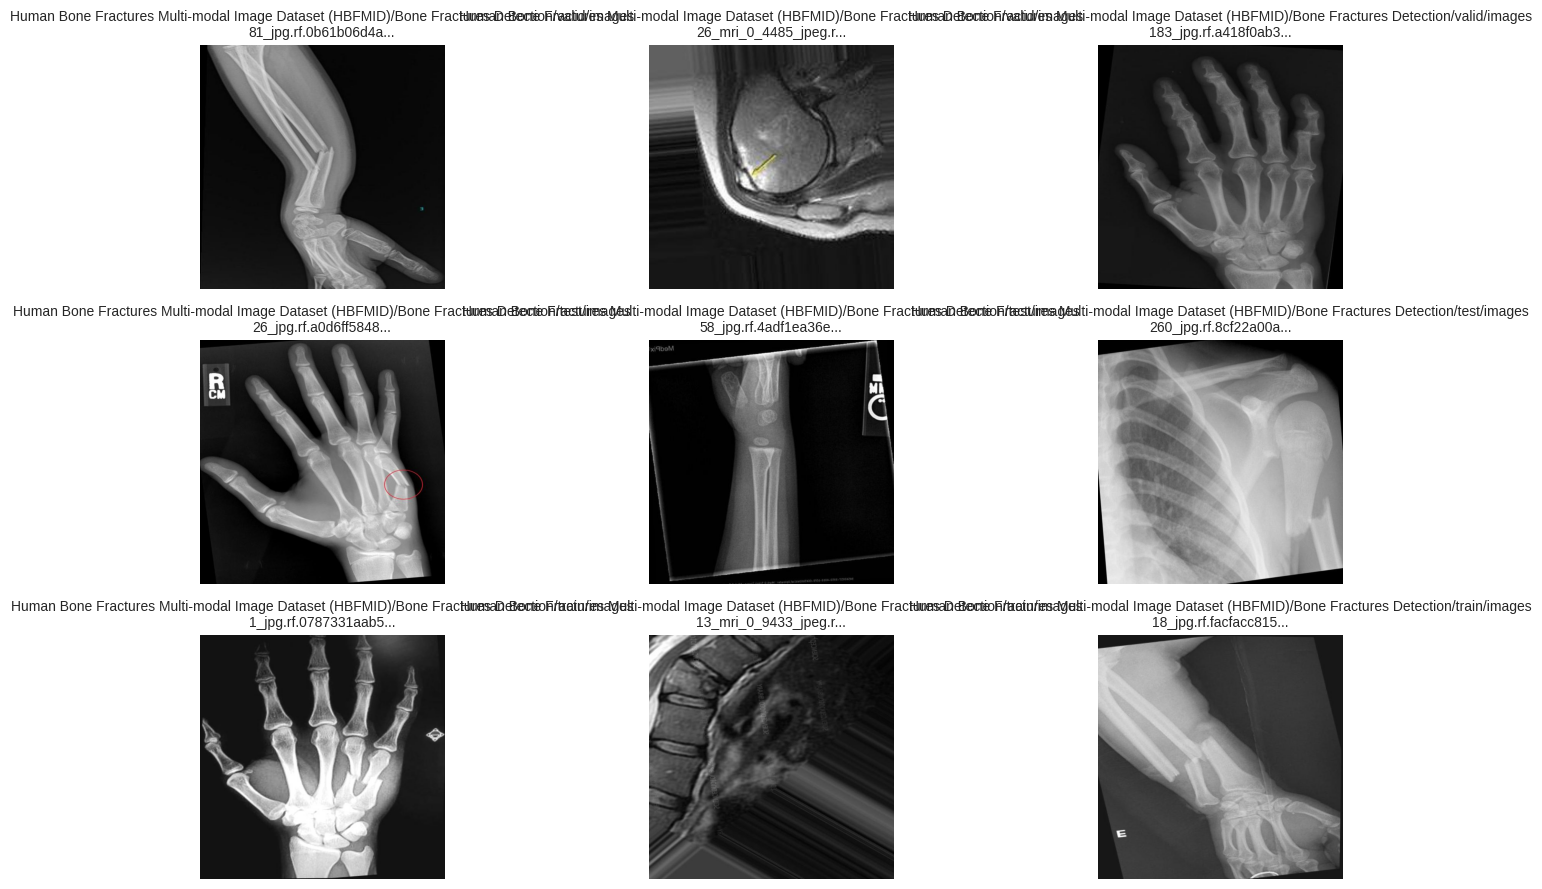

In [33]:
# Display sample images from different directories
def display_sample_images(df, samples_per_dir=3):
    directories = df['directory'].unique()[:6]  # Show up to 6 directories
    
    n_dirs = len(directories)
    fig, axes = plt.subplots(n_dirs, samples_per_dir, figsize=(15, 3*n_dirs))
    
    if n_dirs == 1:
        axes = axes.reshape(1, -1)
    
    for i, directory in enumerate(directories):
        dir_images = df[df['directory'] == directory].sample(min(samples_per_dir, len(df[df['directory'] == directory])))
        
        for j, (_, row) in enumerate(dir_images.iterrows()):
            try:
                img = Image.open(row['filepath'])
                if img.mode in ['L', 'RGB', 'RGBA']:
                    axes[i, j].imshow(img, cmap='gray' if img.mode == 'L' else None)
                else:
                    img_array = np.array(img)
                    axes[i, j].imshow(img_array, cmap='gray')
                
                axes[i, j].set_title(f"{directory}\n{row['filename'][:20]}...", fontsize=10)
                axes[i, j].axis('off')
                
            except Exception as e:
                axes[i, j].text(0.5, 0.5, f"Error loading\n{row['filename']}", 
                               ha='center', va='center', transform=axes[i, j].transAxes)
                axes[i, j].set_title(f"{directory} - Error", fontsize=10)
                axes[i, j].axis('off')
    
    # Hide empty subplots
    for i in range(n_dirs):
        for j in range(len(dir_images), samples_per_dir):
            if j < samples_per_dir:
                axes[i, j].axis('off')
    
    plt.tight_layout()
    plt.show()

print("🖼️ SAMPLE IMAGES FROM DATASET")
print("=" * 40)
display_sample_images(df)

In [34]:
# Analyze image quality metrics (brightness, contrast, etc.)
def calculate_image_metrics(file_path, sample_size=(224, 224)):
    """Calculate various image quality metrics"""
    try:
        # Load image
        img = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None
        
        # Resize for consistent analysis
        img_resized = cv2.resize(img, sample_size)
        
        # Calculate metrics
        metrics = {
            'mean_intensity': np.mean(img_resized),
            'std_intensity': np.std(img_resized),
            'brightness': np.mean(img_resized) / 255.0,
            'contrast': np.std(img_resized) / 255.0,
            'entropy': -np.sum((np.histogram(img_resized, bins=256)[0] / img_resized.size) * 
                              np.log2(np.histogram(img_resized, bins=256)[0] / img_resized.size + 1e-10))
        }
        
        return metrics
    except Exception as e:
        return None

# Calculate metrics for a sample of images (to avoid long processing time)
sample_size = min(200, len(df))  # Analyze up to 200 images
sample_df = df.sample(sample_size, random_state=42)

print(f"🔍 Calculating image quality metrics for {sample_size} sample images...")

metrics_list = []
for idx, row in sample_df.iterrows():
    metrics = calculate_image_metrics(row['filepath'])
    if metrics:
        metrics['directory'] = row['directory']
        metrics_list.append(metrics)

metrics_df = pd.DataFrame(metrics_list)

if not metrics_df.empty:
    print("✅ Metrics calculated successfully!")
    print(f"Metrics available for {len(metrics_df)} images")
    print("\n📊 Quality Metrics Summary:")
    print(metrics_df.describe())
else:
    print("⚠️ No metrics could be calculated")

🔍 Calculating image quality metrics for 200 sample images...
✅ Metrics calculated successfully!
Metrics available for 200 images

📊 Quality Metrics Summary:
       mean_intensity  std_intensity  brightness    contrast     entropy
count      200.000000     200.000000  200.000000  200.000000  200.000000
mean        65.672559      60.227734    0.257539    0.236187    6.063285
std         25.269126      12.835329    0.099095    0.050335    1.140735
min         15.357262      25.790857    0.060225    0.101141    2.763964
25%         48.504649      52.141724    0.190214    0.204477    5.423185
50%         62.107970      61.886152    0.243561    0.242691    6.214491
75%         80.903535      68.619758    0.317269    0.269097    6.989602
max        168.624462      97.286226    0.661272    0.381515    7.739732


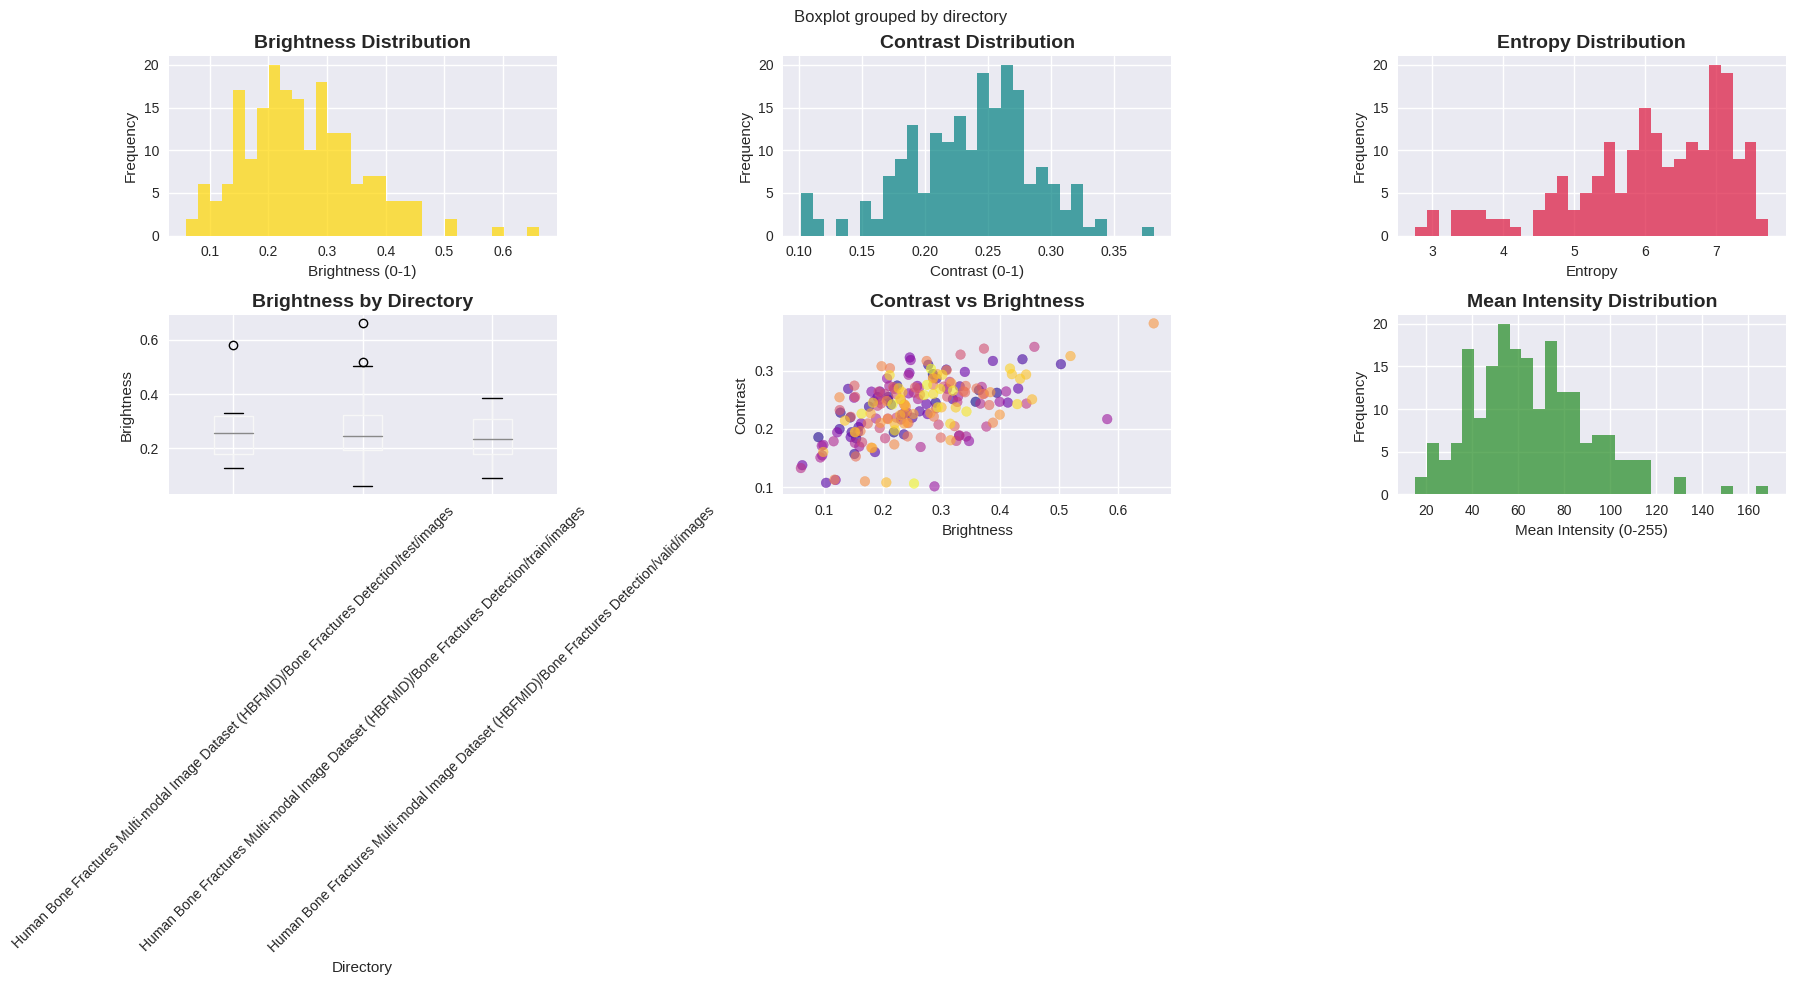

In [35]:
# Visualize image quality metrics
if not metrics_df.empty:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Brightness distribution
    axes[0,0].hist(metrics_df['brightness'], bins=30, color='gold', alpha=0.7)
    axes[0,0].set_title('Brightness Distribution', fontsize=14, fontweight='bold')
    axes[0,0].set_xlabel('Brightness (0-1)')
    axes[0,0].set_ylabel('Frequency')
    
    # Contrast distribution
    axes[0,1].hist(metrics_df['contrast'], bins=30, color='teal', alpha=0.7)
    axes[0,1].set_title('Contrast Distribution', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Contrast (0-1)')
    axes[0,1].set_ylabel('Frequency')
    
    # Entropy distribution
    axes[0,2].hist(metrics_df['entropy'], bins=30, color='crimson', alpha=0.7)
    axes[0,2].set_title('Entropy Distribution', fontsize=14, fontweight='bold')
    axes[0,2].set_xlabel('Entropy')
    axes[0,2].set_ylabel('Frequency')
    
    # Brightness by directory
    if 'directory' in metrics_df.columns:
        metrics_df.boxplot(column='brightness', by='directory', ax=axes[1,0])
        axes[1,0].set_title('Brightness by Directory', fontsize=14, fontweight='bold')
        axes[1,0].set_xlabel('Directory')
        axes[1,0].set_ylabel('Brightness')
        plt.setp(axes[1,0].xaxis.get_majorticklabels(), rotation=45)
    
    # Contrast vs Brightness scatter
    scatter = axes[1,1].scatter(metrics_df['brightness'], metrics_df['contrast'], 
                               alpha=0.6, c=metrics_df.index, cmap='plasma')
    axes[1,1].set_title('Contrast vs Brightness', fontsize=14, fontweight='bold')
    axes[1,1].set_xlabel('Brightness')
    axes[1,1].set_ylabel('Contrast')
    
    # Mean intensity distribution
    axes[1,2].hist(metrics_df['mean_intensity'], bins=30, color='forestgreen', alpha=0.7)
    axes[1,2].set_title('Mean Intensity Distribution', fontsize=14, fontweight='bold')
    axes[1,2].set_xlabel('Mean Intensity (0-255)')
    axes[1,2].set_ylabel('Frequency')
    
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ Skipping quality visualizations - no metrics available")

In [36]:
# Create comprehensive dataset summary
print("📋 DATASET SUMMARY REPORT")
print("=" * 60)
print(f"📁 Total Images: {len(df):,}")
print(f"📂 Directories: {df['directory'].nunique()}")
print(f"💾 Total Dataset Size: {df['file_size_mb'].sum():.2f} MB")
print(f"📏 Average Image Size: {df['file_size_mb'].mean():.3f} MB")

print(f"\n🖼️ IMAGE CHARACTERISTICS")
print(f"Average Dimensions: {df['width'].mean():.0f} x {df['height'].mean():.0f} pixels")
print(f"Most Common Extension: {df['extension'].mode()[0]}")
print(f"Most Common Mode: {df['mode'].mode()[0]}")

# Directory breakdown
print(f"\n📊 DIRECTORY BREAKDOWN")
dir_stats = df['directory'].value_counts()
for directory, count in dir_stats.items():
    percentage = (count / len(df)) * 100
    print(f"  {directory}: {count:,} images ({percentage:.1f}%)")

# Quality insights (if available)
if not metrics_df.empty:
    print(f"\n🔍 QUALITY INSIGHTS (Sample of {len(metrics_df)} images)")
    print(f"Average Brightness: {metrics_df['brightness'].mean():.3f}")
    print(f"Average Contrast: {metrics_df['contrast'].mean():.3f}")
    print(f"Average Entropy: {metrics_df['entropy'].mean():.2f}")

# Recommendations
print(f"\n💡 RECOMMENDATIONS FOR MACHINE LEARNING")
print("─" * 50)

if df['width'].std() > 100 or df['height'].std() > 100:
    print("• ⚠️ High variation in image dimensions - consider resizing for ML models")
    print(f"  Dimension std: Width={df['width'].std():.1f}, Height={df['height'].std():.1f}")

if len(df['extension'].unique()) > 1:
    print("• 🔄 Multiple file formats detected - ensure consistent preprocessing")

class_balance = df['directory'].value_counts()
if len(class_balance) > 1 and (class_balance.max() / class_balance.min()) > 3:
    print("• ⚖️ Class imbalance detected - consider data augmentation or sampling strategies")

print("• 🎯 Suggested preprocessing steps:")
print("  - Resize images to consistent dimensions (e.g., 224x224 or 256x256)")
print("  - Normalize pixel values to [0,1] range")
print("  - Apply data augmentation if class imbalance exists")
print("  - Consider converting all images to same color mode")

print(f"\n✅ EDA COMPLETE!")
print("Dataset is ready for machine learning model development.")

📋 DATASET SUMMARY REPORT
📁 Total Images: 1,539
📂 Directories: 3
💾 Total Dataset Size: 39.33 MB
📏 Average Image Size: 0.026 MB

🖼️ IMAGE CHARACTERISTICS
Average Dimensions: 640 x 640 pixels
Most Common Extension: .jpg
Most Common Mode: RGB

📊 DIRECTORY BREAKDOWN
  Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/train/images: 1,347 images (87.5%)
  Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid/images: 128 images (8.3%)
  Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images: 64 images (4.2%)

🔍 QUALITY INSIGHTS (Sample of 200 images)
Average Brightness: 0.258
Average Contrast: 0.236
Average Entropy: 6.06

💡 RECOMMENDATIONS FOR MACHINE LEARNING
──────────────────────────────────────────────────
• ⚖️ Class imbalance detected - consider data augmentation or sampling strategies
• 🎯 Suggested preprocessing steps:
  - Resize images to consistent dimensions (e.g., 224x224 or 256x256)

In [37]:
# Export the analysis results
def export_results(df, metrics_df=None):
    """Export EDA results to files"""
    
    # Create summary statistics
    summary_stats = {
        'total_images': len(df),
        'directories': df['directory'].nunique(),
        'total_size_mb': df['file_size_mb'].sum(),
        'avg_width': df['width'].mean(),
        'avg_height': df['height'].mean(),
        'directory_distribution': df['directory'].value_counts().to_dict(),
        'extension_distribution': df['extension'].value_counts().to_dict()
    }
    
    # Save main DataFrame
    df.to_csv('image_metadata.csv', index=False)
    print("✅ Saved: image_metadata.csv")
    
    # Save metrics if available
    if metrics_df is not None and not metrics_df.empty:
        metrics_df.to_csv('image_quality_metrics.csv', index=False)
        print("✅ Saved: image_quality_metrics.csv")
    
    # Save summary as JSON-like text file
    with open('dataset_summary.txt', 'w') as f:
        f.write("HUMAN BONE FRACTURES DATASET - EDA SUMMARY\n")
        f.write("=" * 50 + "\n\n")
        for key, value in summary_stats.items():
            f.write(f"{key}: {value}\n")
    
    print("✅ Saved: dataset_summary.txt")
    print("\n📁 Files saved in current working directory")

# Uncomment to export results
# export_results(df, metrics_df if 'metrics_df' in locals() else None)
print("💾 To export results, uncomment the last line and run this cell")

💾 To export results, uncomment the last line and run this cell
